## Codveda Level 2 — Task 3: K-Means Clustering

### Iris Flower Clustering

### Objective
The objective of this project is to group similar Iris flowers using
K-Means clustering based on their numerical measurements.

The dataset will first be standardized, the optimal number of clusters
will be identified using the elbow method, and the resulting clusters
will then be visualized.

In [24]:
#Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#import KMeans libraries
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


In [25]:
# load the dataset
df = pd.read_csv("../../Data Set For Task-20260909T210001Z-1-001/Data Set For Task/1) iris.csv")

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [26]:
df.shape

(150, 5)

In [27]:
#Data Quality Check
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [28]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [29]:
df.duplicated().sum()

np.int64(3)

In [30]:
#Select the clustering features
x = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]

In [31]:
x.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [32]:
x.shape

(150, 4)

In [33]:
#Standardize the Data
scaler = StandardScaler()

x_scaled = scaler.fit_transform(x)

x_scaled[:5]

array([[-0.90068117,  1.03205722, -1.3412724 , -1.31297673],
       [-1.14301691, -0.1249576 , -1.3412724 , -1.31297673],
       [-1.38535265,  0.33784833, -1.39813811, -1.31297673],
       [-1.50652052,  0.10644536, -1.2844067 , -1.31297673],
       [-1.02184904,  1.26346019, -1.3412724 , -1.31297673]])

In [34]:
#determine the optimal number of clusters using the elbow method
k_rng = range(1,11)

sse = []

for k in k_rng:
    km = KMeans(n_clusters= k, random_state=42, n_init=10)
    km.fit(x_scaled)

    sse.append(km.inertia_)

sse


c:\Users\ASUS\anaconda3\envs\codveda_project\Lib\site-packages\sklearn\cluster\_kmeans.py:1424: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\ASUS\anaconda3\envs\codveda_project\Lib\site-packages\sklearn\cluster\_kmeans.py:1424: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\ASUS\anaconda3\envs\codveda_project\Lib\site-packages\sklearn\cluster\_kmeans.py:1424: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\ASUS\anaconda3\envs\codveda_project\Lib\site-packages\sklearn\clust

[600.0,
 223.73200573676345,
 140.96581663074699,
 114.61788585776677,
 91.29544474066981,
 81.75658187204954,
 71.31982095188795,
 62.65176715031906,
 55.261841196034645,
 50.62316902954044]

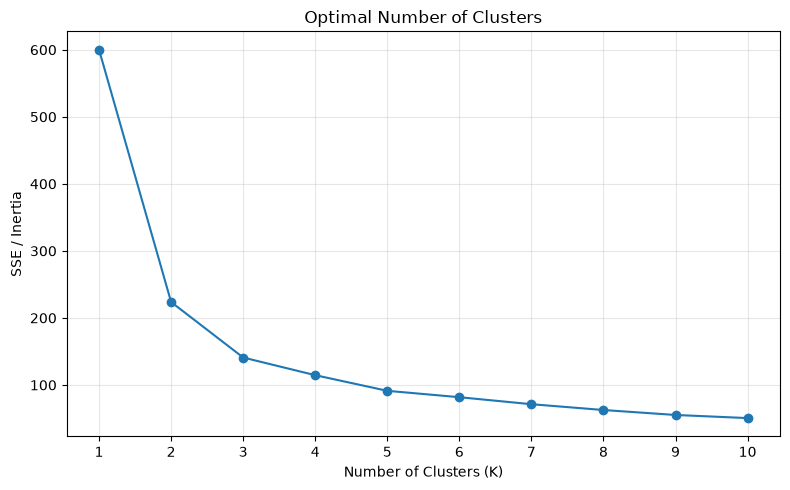

In [35]:
#Plot the elbow curve
plt.figure(figsize=(8, 5))

plt.plot (k_rng, sse, marker='o')

plt.title('Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('SSE / Inertia')

plt.xticks(range(1, 11))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Elbow Method Interpretation

The elbow curve shows a large reduction in inertia from K=1 to K=3.
After K=3, the decrease becomes much more gradual.

Therefore, K=3 was selected as the optimal number of clusters.

In [36]:
#Fit K-Means with 3 clusters

km = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = km.fit_predict(x_scaled)

clusters

c:\Users\ASUS\anaconda3\envs\codveda_project\Lib\site-packages\sklearn\cluster\_kmeans.py:1424: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 2, 2, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 2,
       0, 0, 0, 0, 2, 0, 0, 0, 0, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 2, 2, 2, 2, 2,
       2, 0, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0], dtype=int32)

In [37]:
#Append Clusters to DataFrame
df['cluster'] = clusters

In [45]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species,cluster
0,5.1,3.5,1.4,0.2,setosa,1
1,4.9,3.0,1.4,0.2,setosa,1
2,4.7,3.2,1.3,0.2,setosa,1
3,4.6,3.1,1.5,0.2,setosa,1
4,5.0,3.6,1.4,0.2,setosa,1


In [39]:
#check the cluster size
df['cluster'].value_counts()

cluster
0    53
1    50
2    47
Name: count, dtype: int64

In [46]:
centers_original = scaler.inverse_transform(
    km.cluster_centers_
)

centers_original

array([[5.80188679, 2.67358491, 4.36981132, 1.41320755],
       [5.006     , 3.418     , 1.464     , 0.244     ],
       [6.78085106, 3.09574468, 5.5106383 , 1.97234043]])

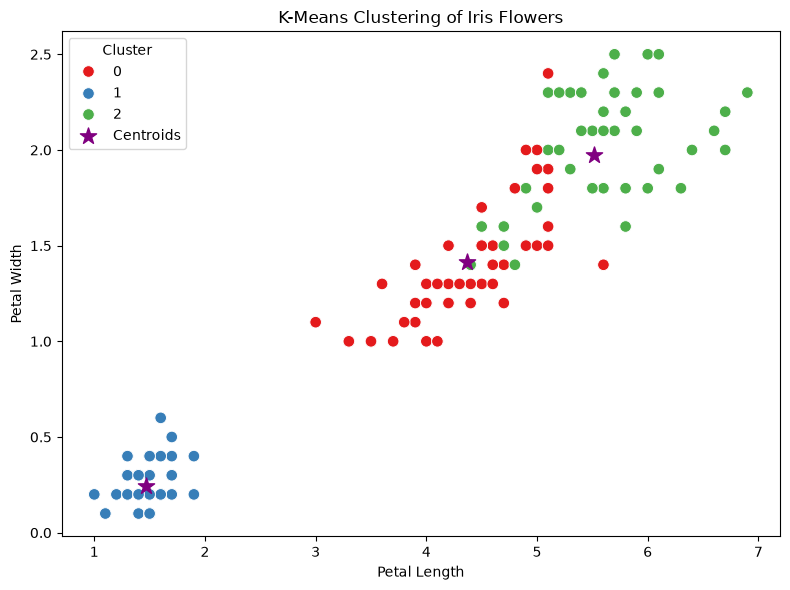

In [41]:
#Visualize the clusters using scatterplot
plt.figure(figsize=(8,6))

sns.scatterplot( data=df,
                x='petal_length',
                y='petal_width',
                hue='cluster',
                palette= 'Set1', s=70)

plt.scatter(
    centers_original[:, 2],
    centers_original[:, 3],
    color= 'purple',
    marker ='*',
    s=150,
    label='Centroids')

plt.title('K-Means Clustering of Iris Flowers')
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.legend(title='Cluster')

plt.tight_layout()
plt.show()

In [42]:
#Compare clusters with actual species
pd.crosstab(
    df['species'],
    df['cluster']
)

cluster,0,1,2
species,,,
setosa,0,50,0
versicolor,39,0,11
virginica,14,0,36


### Cluster Comparison with Actual Species

The K-Means model was trained without using the `species` labels.

After clustering, the discovered clusters were compared with the actual
species:

- Cluster 1 corresponds closely to Setosa, with all Setosa observations
  assigned to this cluster.
- Cluster 0 contains most Versicolor observations, although some
  Virginica observations are also included.
- Cluster 2 contains most Virginica observations, with some overlap
  from Versicolor.

This indicates that Setosa is highly distinct based on the numerical
features, while Versicolor and Virginica have more similar measurements
and are therefore more difficult for K-Means to separate perfectly.

## Key Findings

1. The elbow method indicated that three clusters were an appropriate
   choice for the Iris dataset.

2. K-Means identified three distinct groups based on the four numerical
   flower measurements.

3. One cluster clearly separated flowers with small petal measurements,
   corresponding closely to Setosa.

4. Versicolor and Virginica showed some overlap, indicating that their
   measurements are more similar than those of Setosa.

5. Petal length and petal width provide a particularly clear visual
   separation of the discovered clusters.

## Conclusion

K-Means clustering was applied to the standardized Iris numerical
features to identify groups of similar flowers.

The elbow method supported the use of three clusters. The resulting
clusters showed strong separation for Setosa, while Versicolor and
Virginica exhibited some overlap.

Overall, the clustering results demonstrate that K-Means can identify
meaningful structure in the Iris dataset without using the known species
labels during model training.